# Monte Carlo flight viewer

Load the pickle generated by `montecarlorunner.py`, reduce each complete RocketPy state history to flight-level metrics with NumPy, and analyze the results with pandas. The plots show distributions of peak altitude, ignition attitude angle from vertical, and maximum 3D velocity.

> Only open pickle files you trust. Python pickle files can execute code while loading.

In [1]:
import pickle
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

## Select the Monte Carlo file

Change `PKL_PATH` if the runner output has a different name. `HISTOGRAM_BINS` accepts an integer or any NumPy histogram strategy such as `"auto"`, `"fd"`, or `"sturges"`.

In [2]:
PROJECT_DIR = Path.cwd().resolve()
if not (PROJECT_DIR / "montecarlorunner.py").is_file():
    PROJECT_DIR = PROJECT_DIR / "rocketpy"

if str(PROJECT_DIR) not in sys.path:
    sys.path.insert(0, str(PROJECT_DIR))

PKL_PATH = PROJECT_DIR / "monte_carlo_flights.pkl"
if not PKL_PATH.is_file():
    PKL_PATH = PROJECT_DIR / "flight_data.pkl"

HISTOGRAM_BINS = "auto"
print(f"Loading: {PKL_PATH}")

Loading: C:\Users\Ejfso\Documents\GitHub\projectblaze\sims\rocketpy\monte_carlo_flights.pkl


## Load and validate the results

In [3]:
from montecarlorunner import load_monte_carlo_output

monte_carlo = load_monte_carlo_output(PKL_PATH)

if not isinstance(monte_carlo, dict):
    raise TypeError("Expected the dictionary format written by montecarlorunner.py")
if monte_carlo.get("format") != "projectblaze.rocketpy.monte_carlo":
    raise ValueError(f"Unsupported Monte Carlo format: {monte_carlo.get('format')!r}")

flights = monte_carlo.get("flights", [])
state_columns = tuple(monte_carlo.get("state_columns", ()))
required_columns = {"time", "z", "vx", "vy", "vz", "e0", "e1", "e2", "e3"}
missing_columns = required_columns.difference(state_columns)
if not flights:
    raise ValueError("The pickle contains no flight records")
if missing_columns:
    raise ValueError(f"Flight state data is missing columns: {sorted(missing_columns)}")

print(f"Loaded {len(flights):,} flight records")
print(f"Created: {monte_carlo.get('created_at_utc', 'unknown')}")

Loaded 50 flight records
Created: 2026-08-23T19:45:41.266621+00:00


## Vectorized flight processing

Altitude is reported as peak height above the launch-site elevation. Ignition angle is calculated from the first quaternion in each stored solution, following the same quaternion convention as the reference processing notebook. Maximum velocity is the largest magnitude of `(vx, vy, vz)`.

In [4]:
column = {name: index for index, name in enumerate(state_columns)}
launch_elevation_m = float(monte_carlo.get("environment", {}).get("elevation") or 0.0)

def quaternion_angle_from_vertical(quaternion):
    quaternion = np.asarray(quaternion, dtype=float)
    norm = np.linalg.norm(quaternion)
    if not np.isfinite(norm) or norm == 0:
        return np.nan
    e0, e1, e2, e3 = quaternion / norm
    vertical_component = e0**2 - e1**2 - e2**2 + e3**2
    return np.degrees(np.arccos(np.clip(vertical_component, -1.0, 1.0)))

metric_records = []
velocity_columns = [column["vx"], column["vy"], column["vz"]]
quaternion_columns = [column["e0"], column["e1"], column["e2"], column["e3"]]

for record_index, flight in enumerate(flights):
    states = np.asarray(flight.get("solution", ()), dtype=float)
    if states.ndim != 2 or states.shape[0] == 0 or states.shape[1] < len(state_columns):
        raise ValueError(f"Flight record {record_index} has an invalid solution array")

    altitude = states[:, column["z"]]
    speed = np.linalg.norm(states[:, velocity_columns], axis=1)
    apogee_index = int(np.nanargmax(altitude))
    ignition_quaternion = states[0, quaternion_columns]

    metric_records.append({
        "simulation_index": flight.get("simulation_index", record_index),
        "rocket_index": flight.get("rocket_index", 0),
        "rocket_name": flight.get("rocket_name") or f"rocket_{flight.get('rocket_index', 0)}",
        "launch_inclination_deg": float(flight.get("launch_angle", np.nan)),
        "ignition_angle_deg_from_vertical": float(flight.get("ignition_angle_deg_from_vertical", quaternion_angle_from_vertical(ignition_quaternion))),
        "ignition_time_s": float(flight.get("ignition_time_s", states[0, column["time"]])),
        "apogee_time_s": float(states[apogee_index, column["time"]]),
        "peak_altitude_m_agl": float(altitude[apogee_index] - launch_elevation_m),
        "peak_altitude_ft_agl": float((altitude[apogee_index] - launch_elevation_m) * 3.28084),
        "max_velocity_m_s": float(np.nanmax(speed)),
        "max_velocity_ft_s": float(np.nanmax(speed) * 3.28084),
    })

flight_metrics = pd.DataFrame.from_records(metric_records)
flight_metrics.head()

,simulation_index,rocket_index,rocket_name,launch_inclination_deg,ignition_angle_deg_from_vertical,ignition_time_s,apogee_time_s,peak_altitude_m_agl,peak_altitude_ft_agl,max_velocity_m_s,max_velocity_ft_s
0,0,0,AMA 4-3 Current Booster - Full Stack -> AMA 4-...,89.711819,3.593070,13.18,182.405286,145766.674341,478237.135845,1879.181814,6165.294864
1,1,0,AMA 4-3 Current Booster - Full Stack -> AMA 4-...,89.777368,3.545136,13.18,182.463592,145853.958945,478523.502665,1879.395488,6165.995892
2,2,0,AMA 4-3 Current Booster - Full Stack -> AMA 4-...,89.744823,4.047963,13.18,182.316531,145639.466768,477819.788150,1879.265155,6165.568292
3,3,0,AMA 4-3 Current Booster - Full Stack -> AMA 4-...,89.465325,3.524344,13.18,182.434497,145813.474872,478390.680900,1879.302164,6165.689713
4,4,0,AMA 4-3 Current Booster - Full Stack -> AMA 4-...,88.523357,5.434432,13.18,181.721179,144749.569832,474900.178689,1878.383941,6162.677169


## Summary statistics

In [5]:
summary_columns = [
    "peak_altitude_ft_agl",
    "ignition_angle_deg_from_vertical",
    "max_velocity_ft_s",
]
summary = (
    flight_metrics.groupby("rocket_name", sort=False)[summary_columns]
    .agg(["count", "mean", "std", "min", "median", "max"])
    .round(2)
)
summary

peak_altitude_ft_agl  \
                                                                  count   
rocket_name                                                               
AMA 4-3 Current Booster - Full Stack -> AMA 4-3...                   50   

                                                                       \
                                                         mean     std   
rocket_name                                                             
AMA 4-3 Current Booster - Full Stack -> AMA 4-3...  477660.93  1932.2   

                                                                          \
                                                          min     median   
rocket_name                                                                
AMA 4-3 Current Booster - Full Stack -> AMA 4-3...  467680.18  478148.39   

                                                               \
                                                          max   
rocket_name                                                     
AMA 4-3 Current Booster - Full Stack -> AMA 4-3...  479952.48   

                                                   ignition_angle_deg_from_vertical  \
                                                                              count   
rocket_name                                                                           
AMA 4-3 Current Booster - Full Stack -> AMA 4-3...                               50   

                                                                             \
                                                    mean   std   min median   
rocket_name                                                                   
AMA 4-3 Current Booster - Full Stack -> AMA 4-3...  3.77  1.13  1.18   3.71   

                                                         max_velocity_ft_s  \
                                                     max             count   
rocket_name                                                                  
AMA 4-3 Current Booster - Full Stack -> AMA 4-3...  8.16                50   

                                                                            \
                                                       mean   std      min   
rocket_name                                                                  
AMA 4-3 Current Booster - Full Stack -> AMA 4-3...  6165.35  1.28  6159.51   

                                                                      
                                                     median      max  
rocket_name                                                           
AMA 4-3 Current Booster - Full Stack -> AMA 4-3...  6165.55  6167.31

## Frequency distributions

Each rocket is plotted separately using shared bin edges so overlaid distributions remain comparable. The Matplotlib widget toolbar supports pan, zoom, and image export.

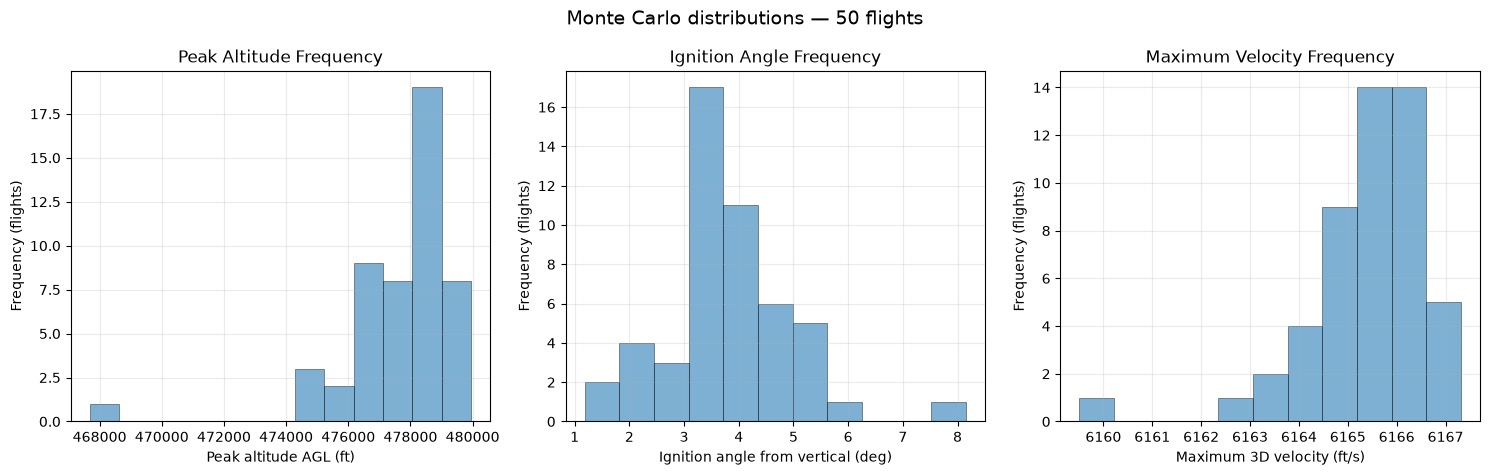

In [6]:
plot_definitions = [
    ("peak_altitude_ft_agl", "Peak altitude AGL (ft)", "Peak Altitude Frequency"),
    ("ignition_angle_deg_from_vertical", "Ignition angle from vertical (deg)", "Ignition Angle Frequency"),
    ("max_velocity_ft_s", "Maximum 3D velocity (ft/s)", "Maximum Velocity Frequency"),
]

fig, axes = plt.subplots(1, 3, figsize=(15, 4.8))
rocket_groups = list(flight_metrics.groupby("rocket_name", sort=False))

for axis, (metric, x_label, title) in zip(axes, plot_definitions):
    all_values = flight_metrics[metric].dropna().to_numpy()
    if all_values.size == 0:
        axis.text(0.5, 0.5, "No valid data", ha="center", va="center")
        continue
    shared_bins = np.histogram_bin_edges(all_values, bins=HISTOGRAM_BINS)
    for rocket_name, group in rocket_groups:
        axis.hist(
            group[metric].dropna(),
            bins=shared_bins,
            alpha=0.58,
            edgecolor="black",
            linewidth=0.5,
            label=rocket_name,
        )
    axis.set_title(title)
    axis.set_xlabel(x_label)
    axis.set_ylabel("Frequency (flights)")
    axis.grid(alpha=0.25)
    if len(rocket_groups) > 1:
        axis.legend()

fig.suptitle(f"Monte Carlo distributions — {len(flight_metrics):,} flights", fontsize=14)
fig.tight_layout()
plt.show()

## Export flight paths and landing points to Google Earth

The export converts RocketPy's local east/north coordinates to latitude and longitude around the launch site stored in the pickle. Flight-path altitude is written as absolute altitude above sea level. A landing placemark is added only when RocketPy reports impact or the final state reaches launch elevation.

`KML_MAX_PATH_POINTS` limits the number of coordinates per flight so large Monte Carlo sweeps remain responsive in Google Earth. Set it to `None` to export every state.

In [7]:
import simplekml

KML_OUTPUT_PATH = PROJECT_DIR / "monte_carlo_flights.kml"
KML_MAX_PATH_POINTS = 2_000
KML_LINE_WIDTH = 3

In [8]:
EARTH_RADIUS_M = 6_378_137.0
environment_metadata = monte_carlo.get("environment", {})
origin_latitude = environment_metadata.get("latitude")
origin_longitude = environment_metadata.get("longitude")
origin_elevation_m = float(environment_metadata.get("elevation") or 0.0)
if origin_latitude is None or origin_longitude is None:
    raise ValueError("The pickle does not contain launch latitude and longitude")
origin_latitude = float(origin_latitude)
origin_longitude = float(origin_longitude)
longitude_scale = EARTH_RADIUS_M * np.cos(np.radians(origin_latitude))
if abs(longitude_scale) < 1e-9:
    raise ValueError("Cannot convert local coordinates at a geographic pole")

def local_xy_to_lon_lat(x_east_m, y_north_m):
    latitude = origin_latitude + np.degrees(float(y_north_m) / EARTH_RADIUS_M)
    longitude = origin_longitude + np.degrees(float(x_east_m) / longitude_scale)
    return longitude, latitude

def path_indices(state_count, maximum_points):
    if maximum_points is None or state_count <= maximum_points:
        return np.arange(state_count, dtype=int)
    return np.unique(np.linspace(0, state_count - 1, maximum_points, dtype=int))

kml = simplekml.Kml(name="Project Blaze Monte Carlo Flights")
paths_folder = kml.newfolder(name="Flight Paths")
landings_folder = kml.newfolder(name="Landing Points")

launch_point = kml.newpoint(
    name="Launch Site",
    coords=[(origin_longitude, origin_latitude, origin_elevation_m)],
)
launch_point.altitudemode = simplekml.AltitudeMode.absolute
launch_point.style.iconstyle.icon.href = "https://maps.google.com/mapfiles/kml/shapes/star.png"
launch_point.style.iconstyle.scale = 1.2

path_colors = [
    simplekml.Color.red,
    simplekml.Color.blue,
    simplekml.Color.green,
    simplekml.Color.orange,
    simplekml.Color.purple,
    simplekml.Color.cyan,
]
export_records = []

for record_index, flight in enumerate(flights):
    states = np.asarray(flight.get("solution", ()), dtype=float)
    if states.ndim != 2 or states.shape[0] == 0:
        continue

    simulation_number = int(flight.get("simulation_index", record_index)) + 1
    rocket_name = flight.get("rocket_name") or f"rocket_{flight.get('rocket_index', 0)}"
    feature_name = f"Run {simulation_number}"
    color = path_colors[record_index % len(path_colors)]
    indices = path_indices(len(states), KML_MAX_PATH_POINTS)
    coordinates = []
    for state in states[indices]:
        longitude, latitude = local_xy_to_lon_lat(state[column["x"]], state[column["y"]])
        coordinates.append((longitude, latitude, float(state[column["z"]])))

    path = paths_folder.newlinestring(name=feature_name, coords=coordinates)
    path.altitudemode = simplekml.AltitudeMode.absolute
    path.tessellate = 1
    path.style.linestyle.color = color
    path.style.linestyle.width = KML_LINE_WIDTH
    path.description = (
        f"States exported: {len(indices):,} of {len(states):,}\n"
        f"Launch inclination: {float(flight.get('launch_angle', np.nan)):.3f} deg"
    )

    events = flight.get("events", {})
    impact_time = events.get("impact_time")
    impact_x = events.get("x_impact")
    impact_y = events.get("y_impact")
    impact_detected = impact_time is not None and impact_x is not None and impact_y is not None
    if not impact_detected and states[-1, column["z"]] <= origin_elevation_m + 1.0:
        impact_detected = True
        impact_time = float(states[-1, column["time"]])
        impact_x = float(states[-1, column["x"]])
        impact_y = float(states[-1, column["y"]])

    if impact_detected:
        landing_longitude, landing_latitude = local_xy_to_lon_lat(impact_x, impact_y)
        landing = landings_folder.newpoint(
            name=f"Landing — {feature_name}",
            coords=[(landing_longitude, landing_latitude, origin_elevation_m)],
        )
        landing.altitudemode = simplekml.AltitudeMode.absolute
        landing.style.iconstyle.color = color
        landing.style.iconstyle.scale = 0.2
        landing.style.iconstyle.icon.href = "https://maps.google.com/mapfiles/kml/shapes/placemark_circle.png"
        landing.description = (
            f"Impact time: {float(impact_time):.2f} s\n"
            f"East offset: {float(impact_x):.1f} m\n"
            f"North offset: {float(impact_y):.1f} m"
        )

    export_records.append({
        "simulation": simulation_number,
        "rocket_name": rocket_name,
        "states_in_pickle": len(states),
        "path_points_exported": len(indices),
        "landing_exported": bool(impact_detected),
    })

KML_OUTPUT_PATH.parent.mkdir(parents=True, exist_ok=True)
kml.save(str(KML_OUTPUT_PATH))
print(f"Saved Google Earth KML: {KML_OUTPUT_PATH}")
pd.DataFrame.from_records(export_records)

Saved Google Earth KML: C:\Users\Ejfso\Documents\GitHub\projectblaze\sims\rocketpy\monte_carlo_flights.kml


,simulation,rocket_name,states_in_pickle,path_points_exported,landing_exported
0,1,FFH 4-3 RCS Booster - Full Stack -> FFH 4-3 RC...,6319,2000,True
1,2,FFH 4-3 RCS Booster - Full Stack -> FFH 4-3 RC...,6462,2000,True
2,3,FFH 4-3 RCS Booster - Full Stack -> FFH 4-3 RC...,6430,2000,True
3,4,FFH 4-3 RCS Booster - Full Stack -> FFH 4-3 RC...,6581,2000,True
4,5,FFH 4-3 RCS Booster - Full Stack -> FFH 4-3 RC...,6561,2000,True
5,6,FFH 4-3 RCS Booster - Full Stack -> FFH 4-3 RC...,6545,2000,True
6,7,FFH 4-3 RCS Booster - Full Stack -> FFH 4-3 RC...,6504,2000,True
7,8,FFH 4-3 RCS Booster - Full Stack -> FFH 4-3 RC...,6473,2000,True
8,9,FFH 4-3 RCS Booster - Full Stack -> FFH 4-3 RC...,6420,2000,True
9,10,FFH 4-3 RCS Booster - Full Stack -> FFH 4-3 RC...,6395,2000,True
